In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

class RACDM:
    def __init__(self, p_grad, x0, alpha, L0, eps=1e-6, max_iters=10000):
        self.p_grad = p_grad
        self.x0 = x0.astype(float).copy()
        self.alpha = alpha
        self.L = L0.copy()
        self.probs = self.L ** alpha / np.sum(self.L ** alpha)
        self.eps = eps
        self.max_iters = max_iters

    def update(self, x):
        i = np.random.choice(len(self.probs), p=self.probs)
        grad_i = self.p_grad(x, i)
        L_hat_i = self.L[i]
        x_new = x.copy()
        x_new[i] -= grad_i / L_hat_i
        grad_i_new = self.p_grad(x_new, i)
        while grad_i * grad_i_new < 0:
            L_hat_i *= 2
            x_new = x.copy()
            x_new[i] -= grad_i / L_hat_i
            grad_i_new = self.p_grad(x_new, i)
        self.L[i] = L_hat_i / 2
        self.probs = self.L ** self.alpha / np.sum(self.L ** self.alpha)
        return x_new

    def solve(self):
        x = self.x0.copy()
        for k in range(self.max_iters):
            x = self.update(x)
            if (k + 1) % 100 == 0:
                full_grad = np.array([self.p_grad(x, i) for i in range(len(x))])
                if np.linalg.norm(full_grad) < self.eps:
                    break
        return x

class GradientDescent:
    def __init__(self, p_grad, x0, eta=1e-3, eps=1e-6, max_iters=10000):
        self.p_grad = p_grad
        self.x0 = x0.astype(float).copy()
        self.eta = eta
        self.eps = eps
        self.max_iters = max_iters

    def update(self, x):
        x_prev = x.copy()
        for i in range(x.shape[0]):
            x[i] -= self.eta * self.p_grad(x_prev, i)
        return x

    def solve(self):
        x = self.x0.copy()
        for k in range(self.max_iters):
            x = self.update(x)
            if (k + 1) % 100 == 0:
                full_grad = np.array([self.p_grad(x, i) for i in range(len(x))])
                if np.linalg.norm(full_grad) < self.eps:
                    break
        return x    
        
Q = np.array([
    [10.,  2.,  1.,  0.],
    [ 2.,  8.,  2.,  1.],
    [ 1.,  2.,  6.,  2.],
    [ 0.,  1.,  2.,  4.]
])

c = np.array([10., -5., 20., -10.])

def p_grad(x, i):
    return (Q @ x - c)[i]

L = np.diag(Q) / 10      

x0 = np.array([100., -100., 100., -100.])

alpha = 0
eps = 1e-5

racdm = RACDM(p_grad, x0, alpha, L, eps)
x_opt = racdm.solve()

x_exact = np.linalg.solve(Q, c)

print("RACDM:", x_opt)
print("Exact: ", x_exact)
print("Error: ", np.linalg.norm(x_opt - x_exact))

RACDM: [ 0.77931535 -1.55134745  5.30954125 -4.76693381]
Exact:  [ 0.77931537 -1.55134741  5.30954115 -4.76693372]
Error:  1.3335079305545004e-07


(100836, 4)
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
610
9724


ValueError: x and y must have same first dimension, but have shapes (20,) and (0,)

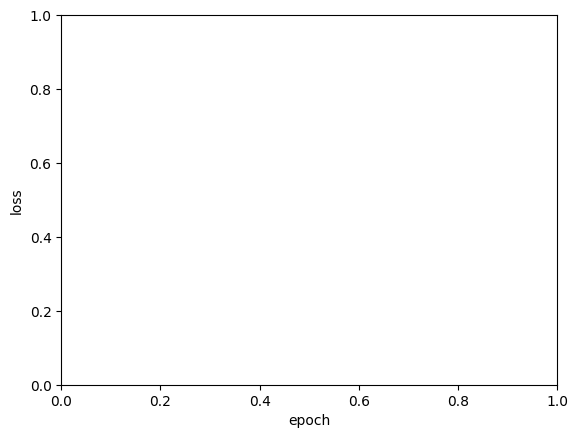

In [ ]:
ratings = pd.read_csv("C:/Users/Varun Bhat/Downloads/ml-latest-small/ratings.csv")

def train_test_split(df, users, test_size=0.2):
    X_train = []
    X_test = []
    y_train = []
    y_test = []

    for user in users:
        rated = df[df['userId'] == user]
        sample = rated.sample(frac=test_size, random_state=42)
        remaining = rated.drop(sample.index)

        for _, row in remaining.iterrows():
            X_train.append((user, row['movieId']))
            y_train.append(row['rating'])

        for _, row in sample.iterrows():
            X_test.append((user, row['movieId']))
            y_test.append(row['rating'])

    return X_train, y_train, X_test, y_test

print(ratings.columns)
print(len(ratings['userId'].unique()))
print(len(ratings['movieId'].unique()))

users = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()

users_map = {users[i] : i for i in range(len(users))}
movie_ids_map = {movie_ids[i] : i for i in range(len(movie_ids))}

X_train, y_train, X_test, y_test = train_test_split(ratings, users, test_size=0.2)

user_idx = np.array([users_map[u] for u, m in X_train])
movie_idx = np.array([movie_ids_map[m] for u, m in X_train])
ratings_arr = np.array(y_train)

user_ratings = {}
movie_ratings = {}

for i, (user, movie_id) in enumerate(X_train):
    user_ratings.setdefault(user, []).append(i)
    movie_ratings.setdefault(movie_id, []).append(i)

user_ratings = {u: np.array(idx) for u, idx in user_ratings.items()}
movie_ratings = {m: np.array(idx) for m, idx in movie_ratings.items()}

n_users = len(users)
n_movies = len(movie_ids)
n_features = 5

def f(U, V):
    preds = np.sum(U[user_idx] * V[movie_idx], axis=1)
    return np.mean((ratings_arr - preds) ** 2)

def u_grad(U, V, u, k):
    idx = user_ratings.get(u)
    if idx is None:
        return 0.0
    preds = np.sum(U[user_idx[idx]] * V[movie_idx[idx]], axis=1)
    return -2 * np.sum((ratings_arr[idx] - preds) * V[movie_idx[idx], k]) / len(ratings_arr)

def m_grad(U, V, m, k):
    idx = movie_ratings.get(m)
    if idx is None:
        return 0.0
    preds = np.sum(U[user_idx[idx]] * V[movie_idx[idx]], axis=1)
    return -2 * np.sum((ratings_arr[idx] - preds) * U[user_idx[idx], k]) / len(ratings_arr)

def u_p_grad(U_flat, i):
    u = i // n_features
    k = i % n_features
    U = U_flat.reshape(n_users, n_features)
    return u_grad(U, V, u, k)

def m_p_grad(V_flat, i):
    m = i // n_features
    k = i % n_features
    V = V_flat.reshape(n_movies, n_features)
    return m_grad(U, V, m, k)

rng = np.random.default_rng(42)

U = rng.normal(0, 0.1, size=(n_users, n_features))
V = rng.normal(0, 0.1, size=(n_movies, n_features))

L_user = np.ones(n_users * n_features)
L_movie = np.ones(n_movies * n_features)

alpha = 0
eps = 1e-6

racdm_user = RACDM(p_grad=u_p_grad, x0=U.ravel(), alpha=alpha, L0=L_user, eps=eps, max_iters=10000)
racdm_movies = RACDM(p_grad=m_p_grad, x0=V.ravel(), alpha=alpha, L0=L_movie, eps=eps, max_iters=100000)

epochs = 20
loss_history = []

for epoch in range(epochs):
    racdm_user.x0 = U.ravel()
    U = racdm_user.solve().reshape(n_users, n_features)
    racdm_movies.x0 = V.ravel()
    V = racdm_movies.solve().reshape(n_movies, n_features)

    loss = f(U, V)
    print(f"Epoch : {epoch} | Loss : {loss}")
    loss_history.append(loss)

plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(list(range(epochs)), loss_history, c='b')
plt.show()
